In [1]:
# IMPORTS

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [3]:
# LOAD BRAZILIAN DATASET

print("Loading Brazilian dataset...")

dataset = load_dataset(
    "joelniklaus/brazilian_court_decisions",
    split="train[:2000]"   # increase later if needed
)

df_br = pd.DataFrame(dataset)

print("Dataset loaded successfully.")
print("Shape:", df_br.shape)
print("Columns:", df_br.columns)

Loading Brazilian dataset...
Dataset loaded successfully.
Shape: (2000, 10)
Columns: Index(['process_number', 'orgao_julgador', 'publish_date', 'judge_relator',
       'ementa_text', 'decision_description', 'judgment_text',
       'judgment_label', 'unanimity_text', 'unanimity_label'],
      dtype='object')


In [5]:
# SELECT REQUIRED COLUMNS


df_br = df_br[[
    "process_number",
    "orgao_julgador",
    "judge_relator",
    "publish_date",
    "ementa_text",
    "decision_description",
    "judgment_label",
    "unanimity_label"
]].dropna().reset_index(drop=True)

print("Documents after cleaning:", len(df_br))

Documents after cleaning: 2000


In [7]:
# TEXT CLEANING FUNCTION


def clean_brazilian_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-zà-ú0-9\s]', ' ', text)
    return text.strip()

In [9]:
# CREATE CLEAN COLUMNS


df_br["ementa_clean"] = df_br["ementa_text"].apply(clean_brazilian_text)
df_br["description_clean"] = df_br["decision_description"].apply(clean_brazilian_text)

print("Clean columns created successfully.")

Clean columns created successfully.


In [ ]:
# BUILD DAERM TEXT


def build_brazilian_daerm(row):

    return f"""
    [COURT]: {row['orgao_julgador']}
    [JUDGE]: {row['judge_relator']}
    [JUDGMENT_LABEL]: {row['judgment_label']}
    [UNANIMITY]: {row['unanimity_label']}

    [LEGAL_SUMMARY]:
    {row['ementa_clean']}
    {row['ementa_clean']}

    [FULL_DESCRIPTION]:
    {row['description_clean']}
    """

df_br["daerm_text"] = df_br.apply(build_brazilian_daerm, axis=1)

In [ ]:
print("DAERM text created successfully.")

In [13]:
# LOAD MODEL


model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully.")

C:\Users\natra\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Model loaded successfully.


In [15]:
# GENERATE EMBEDDINGS


print("Generating DAERM embeddings...")

embeddings_br = model.encode(
    df_br["daerm_text"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings_br.shape)

Generating DAERM embeddings...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [17]:
# KMEANS CLUSTERING


n_clusters = 8

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_br["cluster"] = kmeans.fit_predict(embeddings_br)

print("Clustering completed.")

Clustering completed.


C:\Users\natra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


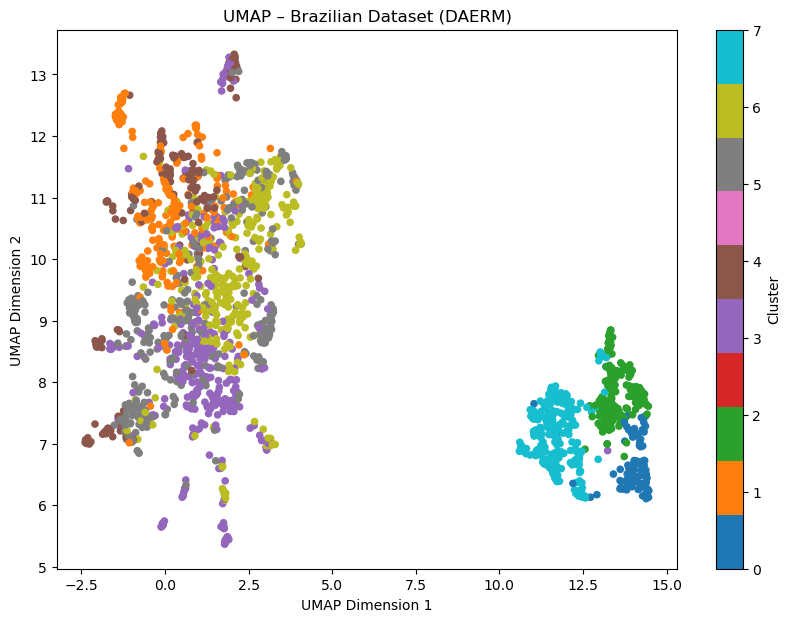

In [19]:
# UMAP VISUALIZATION


umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine",
    random_state=42
)

umap_embeddings = umap_model.fit_transform(embeddings_br)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    umap_embeddings[:,0],
    umap_embeddings[:,1],
    c=df_br["cluster"],
    cmap="tab10",
    s=20
)

plt.colorbar(scatter, label="Cluster")
plt.title("UMAP – Brazilian Dataset (DAERM)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

In [21]:
# SEARCH + VALIDATE SIMILAR CASES (DAERM)

def extract_keywords(text):
    words = text.split()
    stop_words = {
        "de","da","do","das","dos","e","a","o","em","para",
        "com","por","que","no","na","se","ao","à","os","as"
    }
    return set([w for w in words if len(w) > 4 and w not in stop_words])


def search_new_case_brazil_daerm(new_text, top_k=5):

    cleaned = clean_brazilian_text(new_text)

    daerm_input = f"""
    [COURT]: unknown
    [JUDGMENT_LABEL]: unknown

    [LEGAL_SUMMARY]:
    {cleaned}
    {cleaned}

    [FULL_DESCRIPTION]:
    {cleaned}
    """

    new_embedding = model.encode(
        [daerm_input],
        convert_to_numpy=True
    )

    scores = cosine_similarity(new_embedding, embeddings_br)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]

    query_keywords = extract_keywords(cleaned)

    print("="*80)
    print("NEW CASE SUMMARY")
    print("="*80)
    print(cleaned[:400])

    print("\n\nMOST SIMILAR BRAZILIAN CASES (DAERM - VALIDATED)")
    print("="*80)

    for rank, i in enumerate(top_idx, start=1):

        row = df_br.iloc[i]
        case_text = row["ementa_clean"]

        case_keywords = extract_keywords(case_text)
        common_terms = query_keywords.intersection(case_keywords)

        print(f"\n🔹 Rank {rank}")
        print("----------------------------------")
        print("Case Number:", row["process_number"])
        print("Court:", row["orgao_julgador"])
        print("Judge:", row["judge_relator"])
        print("Similarity Score:", round(float(scores[i]), 3))

        print("Keyword Overlap Count:", len(common_terms))
        
        if len(common_terms) > 0:
            print("Common Legal Terms:", list(common_terms)[:6])
        else:
            print("Reason: Contextual semantic similarity captured by transformer.")

        print("Preview:", case_text[:300])

In [33]:
new_case = """
Trata-se de recurso relacionado a indenização por danos morais
decorrentes de acidente de trânsito com pedido de compensação financeira.
"""

search_new_case_brazil_daerm(new_case)

NEW CASE SUMMARY
trata se de recurso relacionado a indenização por danos morais decorrentes de acidente de trânsito com pedido de compensação financeira


MOST SIMILAR BRAZILIAN CASES (DAERM - VALIDATED)

🔹 Rank 1
----------------------------------
Case Number: 0004052-14.2012.8.02.0058
Court: 3ª Câmara Cível
Judge: Des. Celyrio Adamastor Tenório Accioly
Similarity Score: 0.74
Keyword Overlap Count: 4
Common Legal Terms: ['trânsito', 'danos', 'recurso', 'acidente']
Preview: apelação cível  responsabilidade civil em acidente de trânsito  ação indenizatória  responsabilidade civil subjetiva  invasão de faixa ocupada pelo apelado  danos materiais  dever de indenizar  dano moral  verificado na espécie  quantum indenizatório arbitrado em r  15 000 00  quinze mil reais  redu

🔹 Rank 2
----------------------------------
Case Number: 0101170-20.2003.8.02.0053
Court: 3ª Câmara Cível
Judge: Des. Domingos de Araújo Lima Neto
Similarity Score: 0.727
Keyword Overlap Count: 6
Common Legal Terms: ['m

In [ ]:
DEARM OUTPUT (English Translation)
NEW CASE SUMMARY

This is an appeal related to compensation for moral damages arising from a traffic accident, with a request for financial compensation.

MOST SIMILAR BRAZILIAN CASES (DAERM – VALIDATED)
🔹 Rank 1

Case Number: 0004052-14.2012.8.02.0058
Court: 3rd Civil Chamber
Judge: Justice Celyrio Adamastor Tenório Accioly
Similarity Score: 0.74
Keyword Overlap Count: 4
Common Legal Terms: ['damages', 'appeal', 'traffic', 'accident']

Reason: Shared legal terminology and domain concepts.

Preview:
Civil appeal – civil liability in traffic accident – compensation action – subjective civil liability 
– invasion of lane occupied by the appellee – material damages – duty to indemnify – moral damage verified in the case – 
compensation amount fixed at R$ 15,000.00 (fifteen thousand reais) – reduction.

🔹 Rank 2

Case Number: 0101170-20.2003.8.02.0053
Court: 3rd Civil Chamber
Judge: Justice Domingos de Araújo Lima Neto
Similarity Score: 0.727
Keyword Overlap Count: 6
Common Legal Terms: ['damages', 'moral', 'compensation', 'appeal', 'traffic', 'accident']

Reason: Shared legal terminology and domain concepts.

Preview:
Civil appeal – action for compensation for material and moral damages – traffic accident – death – liability of the appellant company – 
objective liability – material damage – pension granted to the appellees – precedent of the STJ – 
interest and monetary correction from the respective due dates.

🔹 Rank 3

Case Number: 0700261-93.2017.8.02.0066
Court: 3rd Civil Chamber
Judge: Justice Domingos de Araújo Lima Neto
Similarity Score: 0.719
Keyword Overlap Count: 3
Common Legal Terms: ['arising', 'traffic', 'request']

Reason: Shared legal terminology and domain concepts.

Preview:
Mandatory review – writ of mandamus – provision of public intermunicipal passenger transport service – state competence – possibility of delegation
– ARSAL competent to plan, coordinate, grant, authorize, regularize and supervise the service – Law No. 6,267/2001.

🔹 Rank 4

Case Number: 0712845-96.2017.8.02.0001
Court: 3rd Civil Chamber
Judge: Justice Celyrio Adamastor Tenório Accioly
Similarity Score: 0.716
Keyword Overlap Count: 1
Common Legal Terms: ['traffic']

Reason: Shared legal terminology and domain concepts.

Preview:
Mandatory review – writ of mandamus – municipal public servant – traffic inspection agent – municipality of Maceió – 
career progression by qualification – completion of higher education exceeding the level required for appointment to the position – article 20, VII, items 1 and 4 of the municipal law.

🔹 Rank 5

Case Number: 0719421-08.2017.8.02.0001
Court: 3rd Civil Chamber
Judge: Justice Celyrio Adamastor Tenório Accioly
Similarity Score: 0.714
Keyword Overlap Count: 1
Common Legal Terms: ['traffic']

Reason: Shared legal terminology and domain concepts.

Preview:
Mandatory review – writ of mandamus – municipal public servant – traffic inspection agent – municipality of Maceió 
– career progression by qualification – completion of higher education exceeding the level required for appointment to the position – 
article 20, VII, items 1 and 4 of the municipal law.

In [ ]:
new_case = """
Trata-se de recurso relacionado a indenização por danos morais
decorrentes de acidente de trânsito com pedido de compensação financeira.
"""

In [ ]:
new_case = """
Trata-se de recurso em ação revisional de contrato bancário.
A parte autora alega cobrança de juros abusivos e requer a
revisão das cláusulas contratuais com restituição dos valores pagos.
"""